# Demand Forecasting: Correcting for Stockout Censoring

A RandomForestRegressor forecasts daily demand per finished good from day-of-week and item identity. The interesting part isn't the model itself -- it's the target.

**The problem:** if you train a demand forecast on *fulfilled* sales, any item that stocks out gets a systematically understated demand signal (you can't sell what you don't have). That understated forecast then feeds back into `inventory_engine.py` reorder sizing, which orders *even less* safety stock next cycle -- a feedback loop that compounds a stockout problem instead of fixing it.

**The fix:** forecast off *requested* quantity, recovered via `COALESCE(original_item_id, item_id)` on `order_lines` -- this captures what the customer actually wanted, whether or not they got it (including what they were substituted away from). This notebook quantifies the difference rather than just asserting it matters.

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
RESULTS = '../data/results'

## 1. Does the censoring bias actually matter here?

Two scenarios, same underlying order history, different inventory policies:
- **High fulfillment** (~97.2%, current Phase 6-optimized policy) -- few stockouts, so censoring should be a small effect
- **Low fulfillment** (~93.6%, deliberately under-provisioned for this test) -- more stockouts, so censoring should be a bigger effect

If the theory is right, the gap between the naive (fulfilled-trained) and correct (requested-trained) model should widen as stockouts get more frequent.

In [4]:
scenarios = {}
for label, suffix in [('High fulfillment (~97%)', 'high_fulfillment'),
                       ('Low fulfillment (~93.6%)', 'low_fulfillment')]:
    with open(f'{RESULTS}/demand_forecast_metrics_{suffix}.json') as f:
        scenarios[label] = json.load(f)

comparison = pd.DataFrame(scenarios).T
comparison[['mae_baseline', 'mae_naive_fulfilled_model', 'mae_correct_requested_model']]

,mae_baseline,mae_naive_fulfilled_model,mae_correct_requested_model
High fulfillment (~97%),9.668498,9.542623,9.554811
Low fulfillment (~93.6%),9.668498,9.634522,9.554811


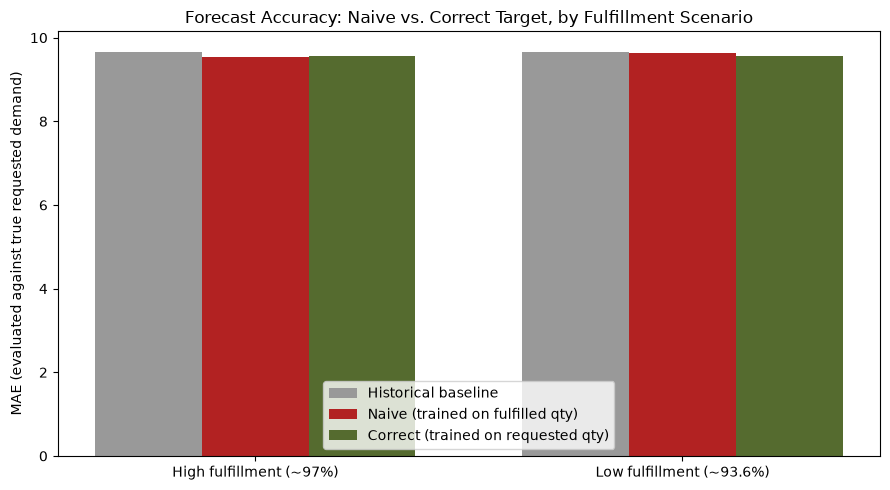

In [5]:
fig, ax = plt.subplots()
x = range(len(comparison))
width = 0.25
ax.bar([i - width for i in x], comparison['mae_baseline'], width, label='Historical baseline', color='#999999')
ax.bar(x, comparison['mae_naive_fulfilled_model'], width, label='Naive (trained on fulfilled qty)', color='#b22222')
ax.bar([i + width for i in x], comparison['mae_correct_requested_model'], width, label='Correct (trained on requested qty)', color='#556b2f')
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index)
ax.set_ylabel('MAE (evaluated against true requested demand)')
ax.set_title('Forecast Accuracy: Naive vs. Correct Target, by Fulfillment Scenario')
ax.legend()
plt.tight_layout()
plt.show()

**Result:** at high fulfillment, the naive and correct models are nearly tied (censoring barely matters when there's little to censor). At low fulfillment, the naive model's MAE gets *worse* while the correct model's MAE stays exactly the same -- it's trained on requested quantity, which doesn't depend on the inventory policy at all. The correct model overtakes the naive one exactly as the theory predicts. This is also a real caution about the current, already-optimized 97% state: don't assume the censoring effect is negligible just because it looks small right now -- it scales directly with how bad your stockouts get.

## 2. Bias by item: who suffers most from stockout censoring?

In [6]:
bias_low = pd.read_csv(f'{RESULTS}/demand_forecast_bias_by_item_low_fulfillment.csv')
bias_low = bias_low.sort_values('stockout_rate', ascending=False)
bias_low

,item_code,stockout_rate,naive_bias,correct_bias
0,FG-FRAPPE-CARAMEL,0.111842,2.442281,4.209615
1,FG-FRAPPE-MOCHA,0.097260,0.290802,1.974846
2,FG-LATTE-SPICED,0.091559,2.772994,4.699684
3,FG-LATTE-MOCHA,0.080780,-1.061425,0.978092
4,FG-COLDBREW,0.070866,0.325051,2.671290
5,FG-LATTE-STD,0.061460,1.581226,4.437363
6,FG-BREWED,0.032685,-1.416605,-0.447578
7,FG-AMERICANO,0.008499,1.398745,1.559373


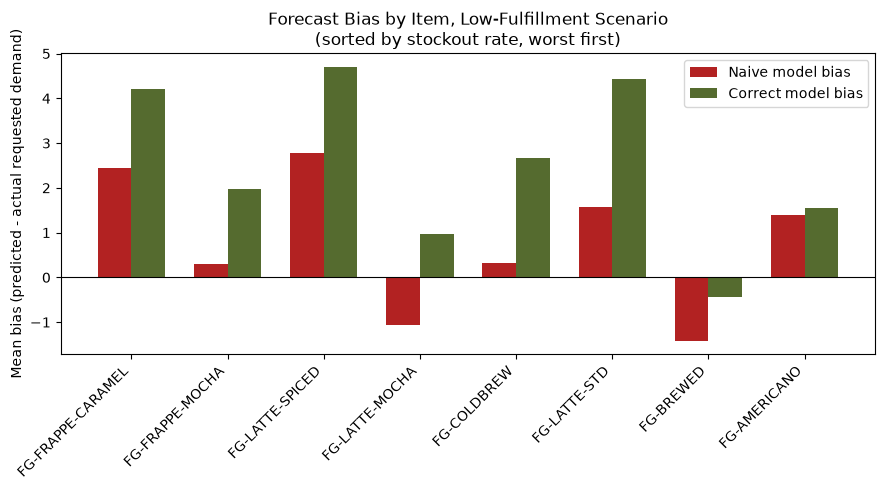

In [7]:
fig, ax = plt.subplots()
x = range(len(bias_low))
width = 0.35
ax.bar([i - width/2 for i in x], bias_low['naive_bias'], width, label='Naive model bias', color='#b22222')
ax.bar([i + width/2 for i in x], bias_low['correct_bias'], width, label='Correct model bias', color='#556b2f')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(bias_low['item_code'], rotation=45, ha='right')
ax.set_ylabel('Mean bias (predicted - actual requested demand)')
ax.set_title('Forecast Bias by Item, Low-Fulfillment Scenario\n(sorted by stockout rate, worst first)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Feature importance
What actually drives the forecast, beyond just item identity.

In [8]:
preds = pd.read_csv(f'{RESULTS}/demand_forecast_predictions_high_fulfillment.csv')
preds['date'] = pd.to_datetime(preds['date'])
preds.head()

,item_id,date,requested_qty,fulfilled_qty,item_code,predicted_requested,predicted_from_fulfilled_model
0,21,2026-07-23,26.0,26.0,FG-LATTE-STD,57.628821,57.603499
1,21,2026-07-24,35.0,35.0,FG-LATTE-STD,54.257840,54.200795
2,21,2026-07-25,44.0,44.0,FG-LATTE-STD,70.892653,70.261134
3,21,2026-07-26,70.0,70.0,FG-LATTE-STD,60.625362,55.762142
4,21,2026-07-27,70.0,70.0,FG-LATTE-STD,49.637064,46.640684


### 3a. Predicted vs. actual, by item

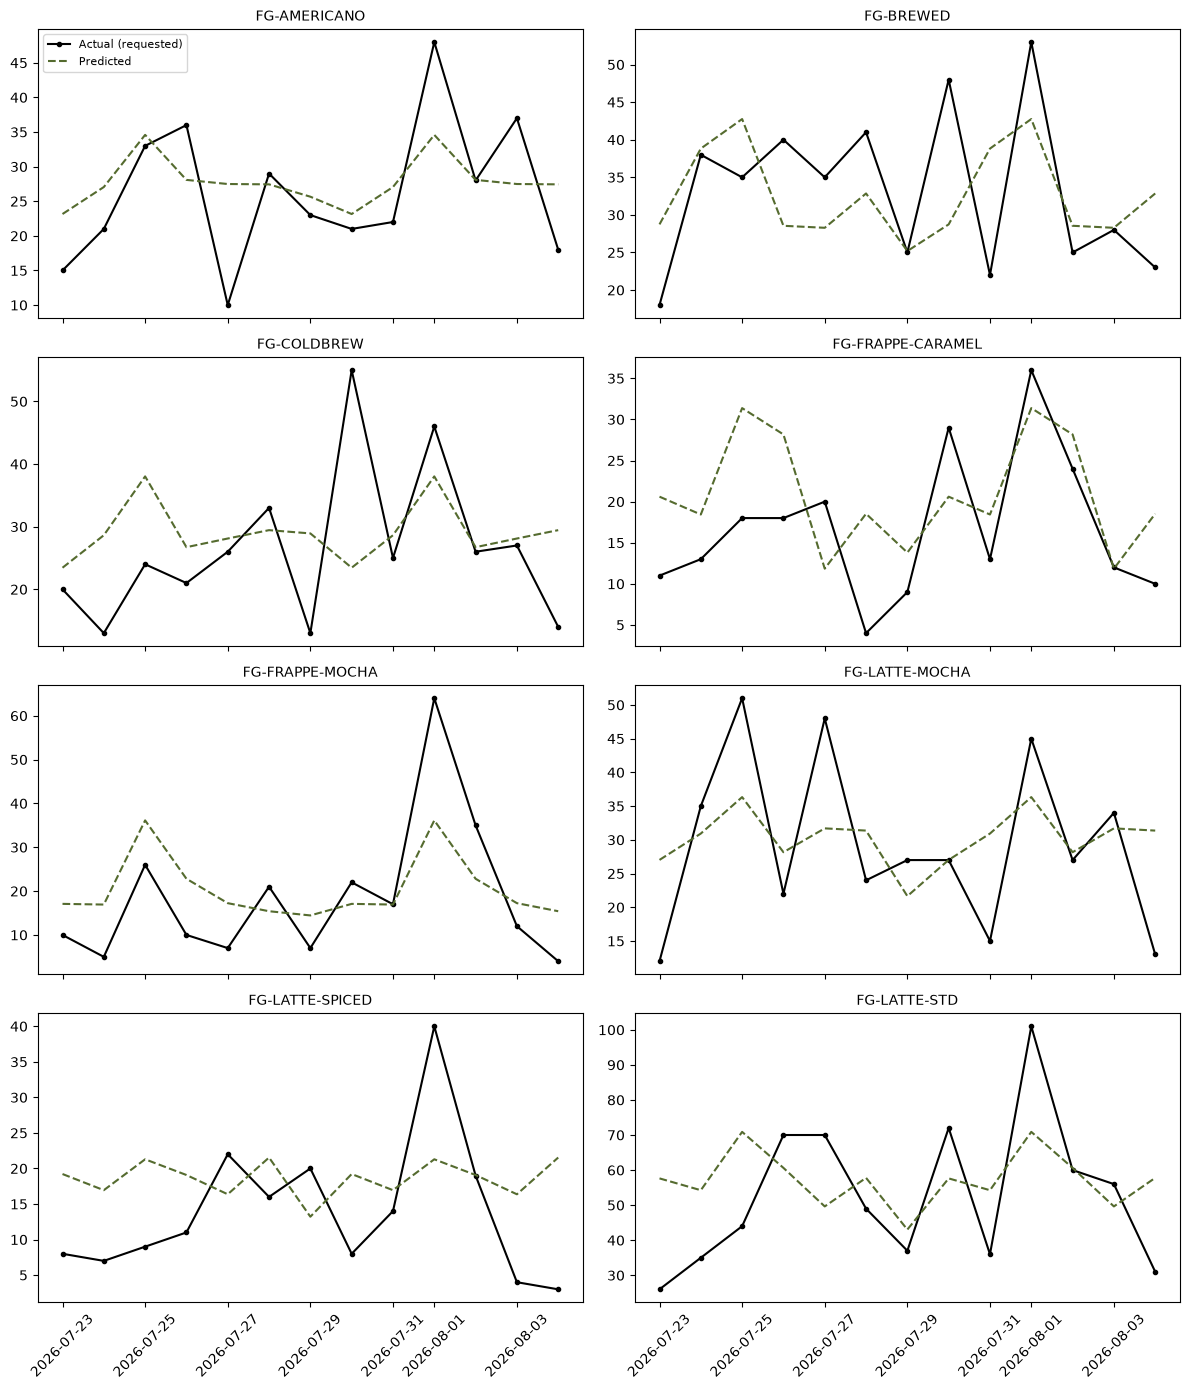

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharex=True)
for ax, code_ in zip(axes.flat, sorted(preds['item_code'].unique())):
    sub = preds[preds.item_code == code_].sort_values('date')
    ax.plot(sub['date'], sub['requested_qty'], label='Actual (requested)', color='black', marker='o', markersize=3)
    ax.plot(sub['date'], sub['predicted_requested'], label='Predicted', color='#556b2f', linestyle='--')
    ax.set_title(code_, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
axes.flat[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Takeaways

- The censoring-bias effect is real and measurable, and scales with how bad your stockouts are -- small when fulfillment is high, more visible as it drops.
- A model correctly trained on requested demand doesn't degrade as fulfillment drops, because its target is invariant to the inventory policy. That's the whole point: it forecasts true demand, not "how much I happened to be able to sell."
- **Update:** this finding led directly to a fix in `optimize_inventory.py`'s `compute_demand_stats()`, which previously read `inventory_transactions` consumption records -- only ever logged when a line was actually fulfilled, meaning Phase 6's own safety-stock calibration had this exact bug. It now explodes true requested demand (`COALESCE(original_item_id, item_id)` on `order_lines`) through the BOM instead. The fix changed the calibrated z for a 97% target from 0.25 to 0.625 -- the old (biased) calibration was telling the system it could run leaner than it actually could, understating required safety stock by about 7% of working capital. Both `optimize_inventory.py` and `live_sim.py`'s periodic recalibration now share the corrected function.